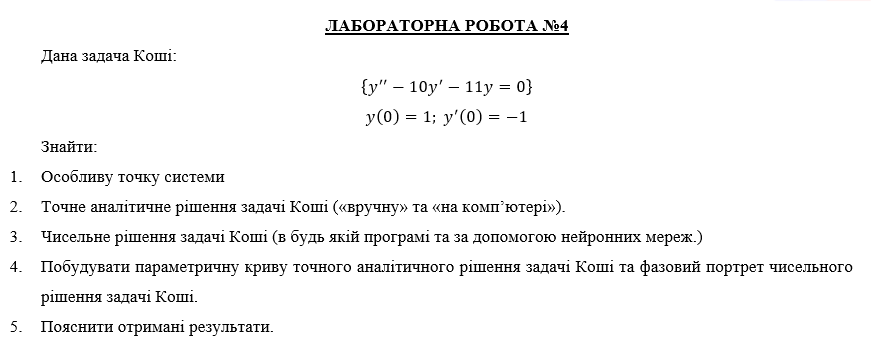

In [1]:
import sympy as sp

t = sp.symbols('t')
y = sp.Function('y')(t)

# Рівняння: y'' - 10y' - 11y = 0
diff_eq = sp.Eq(y.diff(t, t) - 10*y.diff(t) - 11*y, 0)

# Початкові умови
ics = {y.subs(t, 0): 1, y.diff(t).subs(t, 0): -1}

# Розв'язання
sol = sp.dsolve(diff_eq, y, ics=ics)
print(f"Аналітичний розв'язок: y(t) = {sol.rhs}")


Аналітичний розв'язок: y(t) = exp(-t)


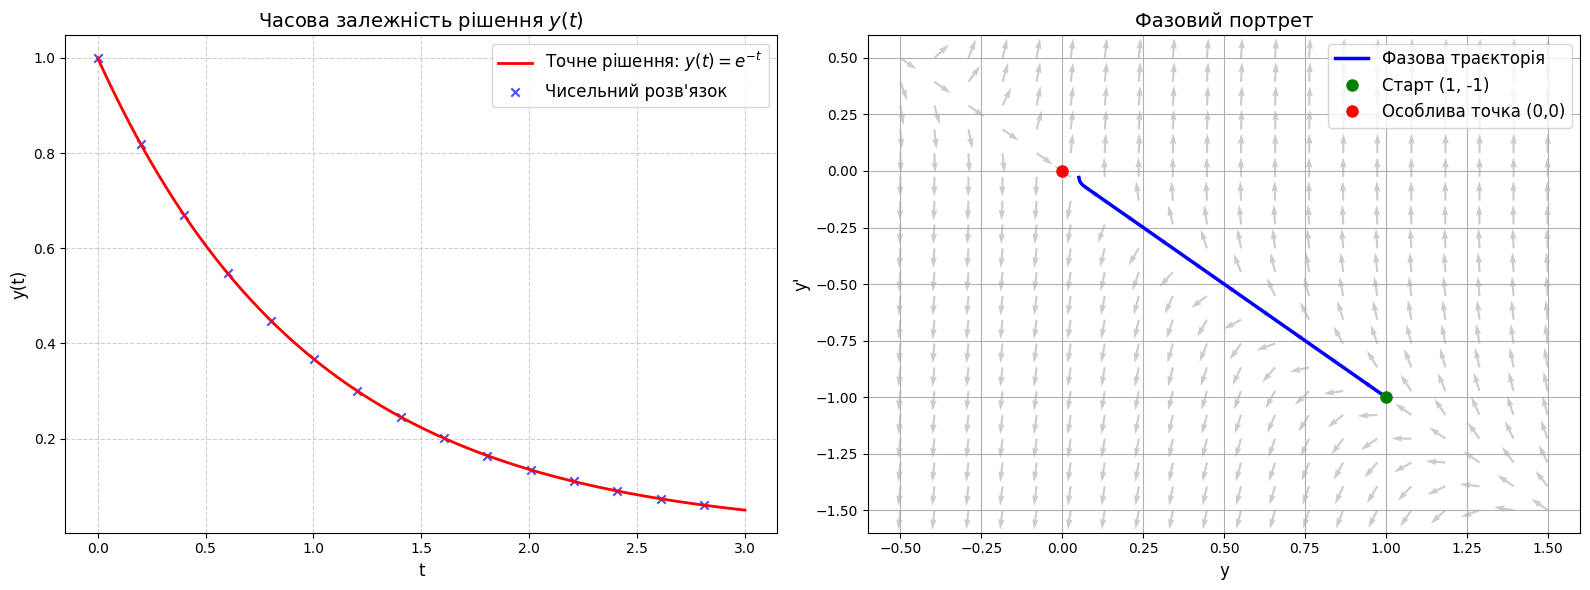

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Система рівнянь для чисельного методу
# y' = x2
# x2' = 10*x2 + 11*y (з рівняння y'' - 10y' - 11y = 0)
def system_ode(state, t):
    y, y_prime = state
    dydt = y_prime
    dy_primedt = 10 * y_prime + 11 * y
    return [dydt, dy_primedt]

# Часовий інтервал
t = np.linspace(0, 3, 300)

# Початкові умови: y(0) = 1, y'(0) = -1
y0 = [1, -1]

# Точне аналітичне рішення y(t) = e^(-t)
y_exact = np.exp(-t)

# чисельне рішення (метод Runge–Kutta)
sol_numeric = odeint(system_ode, y0, t)
y_num = sol_numeric[:, 0]      # y
y_prime_num = sol_numeric[:, 1] # y'


fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Точне аналітичне рішення
ax[0].plot(t, y_exact, 'r-', linewidth=2, label=r'Точне рішення: $y(t) = e^{-t}$')
ax[0].scatter(t[::20], y_num[::20], color='blue', marker='x', label='Чисельний розв\'язок', alpha=0.7)
ax[0].set_title("Часова залежність рішення $y(t)$", fontsize=14)
ax[0].set_xlabel("t", fontsize=12)
ax[0].set_ylabel("y(t)", fontsize=12)
ax[0].grid(True, linestyle='--', alpha=0.6)
ax[0].legend(fontsize=12)

# Фазовий портрет чисельного рішення
# векторне поле
Y_val = np.linspace(-0.5, 1.5, 20)
YP_val = np.linspace(-1.5, 0.5, 20)
Y, YP = np.meshgrid(Y_val, YP_val)

# Вектори швидкості у кожній точці фазової площини
U = YP
V = 10 * YP + 11 * Y

# Нормалізація векторів для кращого вигляду стрілок
N = np.sqrt(U**2 + V**2)
U, V = U/N, V/N

ax[1].quiver(Y, YP, U, V, color='gray', alpha=0.4, angles='xy')

# траєкторіz чисельного рішення
ax[1].plot(y_num, y_prime_num, 'b-', linewidth=2.5, label='Фазова траєкторія')
ax[1].plot(y0[0], y0[1], 'go', markersize=8, label='Старт (1, -1)')
ax[1].plot(0, 0, 'ro', markersize=8, label='Особлива точка (0,0)')

# Налаштування
ax[1].set_title("Фазовий портрет", fontsize=14)
ax[1].set_xlabel("y", fontsize=12)
ax[1].set_ylabel("y'", fontsize=12)
ax[1].grid(True)
ax[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

Починаємо навчання нейромережі...
Epoch 0, Loss: 20.283882
Epoch 500, Loss: 0.026545
Epoch 1000, Loss: 0.005810
Epoch 1500, Loss: 0.002012
Навчання завершено.


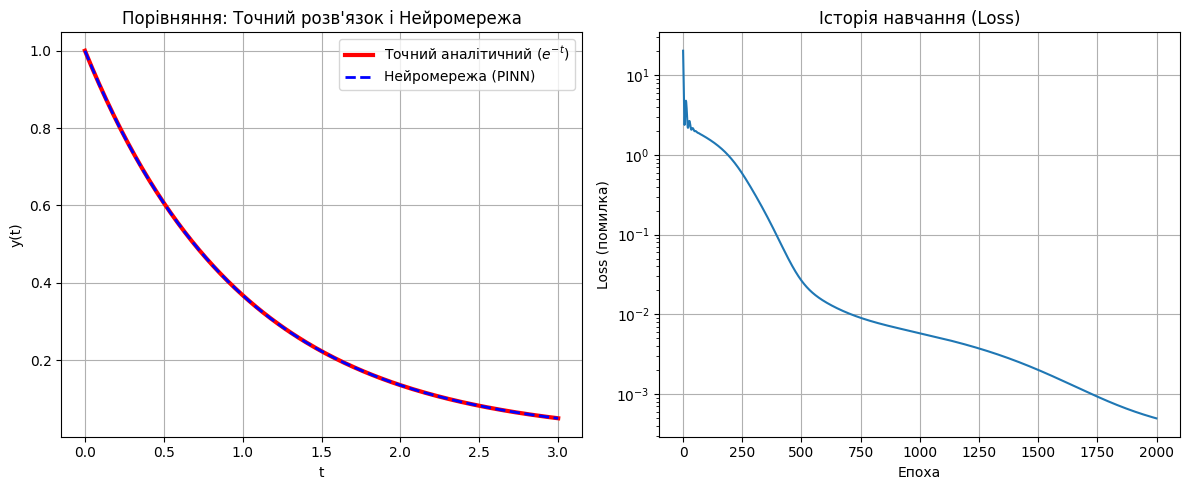

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Створення Нейромережі
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        # Проста мережа: 1 вхід (t) -> 2 приховані шари по 32 нейрони -> 1 вихід (y)
        # Tanh використовується тому, що він гладкий і має неперервні похідні (краще для диф. рівнянь)
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

# Функція для обчислення похідних
def get_derivatives(model, t):
    """
    Обчислює y, y' та y'' використовуючи автоматичне диференціювання PyTorch
    """
    t.requires_grad = True # Дозволяємо відстежувати градієнти по t
    y = model(t)

    # Перша похідна dy/dt
    # create_graph=True потрібен, щоб потім взяти похідну від похідної
    dy = torch.autograd.grad(y, t, torch.ones_like(y), create_graph=True)[0]

    # Друга похідна d^2y/dt^2
    d2y = torch.autograd.grad(dy, t, torch.ones_like(dy), create_graph=True)[0]

    return y, dy, d2y

# Підготовка до навчання
model = PINN()
optimizer = optim.Adam(model.parameters(), lr=0.001) # Оптимізатор Adam

# Точки тренування: беремо випадкові точки на інтервалі [0, 3]
# Інтервал невеликий, бо рішення швидко прямує до нуля
t_train = torch.linspace(0, 3, 100).view(-1, 1)

# Навчання нейромережі
epochs = 2000
loss_history = []

print("Починаємо навчання нейромережі...")

for epoch in range(epochs):
    optimizer.zero_grad()

    # Обчислення значень функції та похідних у точках t
    y_pred, dy_pred, d2y_pred = get_derivatives(model, t_train)

    # Loss для рівняння y'' - 10y' - 11y = 0  - мінімізація різниці лівої частини від 0
    ode_residual = d2y_pred - 10*dy_pred - 11*y_pred
    loss_ode = torch.mean(ode_residual**2)

    # Loss початкових умов (Boundary Loss)
    # Умова: t=0
    t0 = torch.tensor([[0.0]], requires_grad=True)
    y0, dy0, _ = get_derivatives(model, t0)

    # y(0) = 1, y'(0) = -1
    loss_ic = (y0 - 1)**2 + (dy0 - (-1))**2

    # Загальний Loss
    loss = loss_ode + loss_ic

    # Зворотне поширення помилки
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

print("Навчання завершено.")

# Візуалізація результатів

# Генерація даних
t_test = torch.linspace(0, 3, 200).view(-1, 1)
with torch.no_grad():
    y_nn = model(t_test).numpy()

# точний розв'язок
t_val = t_test.numpy()
y_exact = np.exp(-t_val)

plt.figure(figsize=(12, 5))

# Графік 1: Порівняння розв'язків
plt.subplot(1, 2, 1)
plt.plot(t_val, y_exact, 'r-', linewidth=3, label='Точний аналітичний ($e^{-t}$)')
plt.plot(t_val, y_nn, 'b--', linewidth=2, label='Нейромережа (PINN)')
plt.title('Порівняння: Точний розв\'язок і Нейромережа')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.legend()
plt.grid(True)

# Графік 2: Графік помилки навчання (Loss)
plt.subplot(1, 2, 2)
plt.plot(loss_history)
plt.yscale('log') # Логарифмічна шкала, щоб краще бачити спадання
plt.title('Історія навчання (Loss)')
plt.xlabel('Епоха')
plt.ylabel('Loss (помилка)')
plt.grid(True)

plt.tight_layout()
plt.show()